## 1. Imports and environment

In [354]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

In [355]:
# Reproductibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cpu


In [356]:
BASE_DIR = Path(r"C:\Users\Diego\PyCharmMiscProject\processed_riga_finale_finale_finale")

EDGE_FILE = BASE_DIR / "embedding_edge_list.csv"
FEATURE_FILE = BASE_DIR / "embedding_feature_matrix.csv"
NODE_FILE = BASE_DIR / "lgia_riga_nodes_enriched_osm.csv"
META_FILE = BASE_DIR / "embedding_metadata.json"

edges_df = pd.read_csv(EDGE_FILE)
features_df = pd.read_csv(FEATURE_FILE)
nodes_df = pd.read_csv(NODE_FILE)

with open(META_FILE, "r", encoding="utf-8") as f:
    metadata = json.load(f)

print("edges_df:", edges_df.shape)
print("features_df:", features_df.shape)
print("nodes_df:", nodes_df.shape)
print("metadata feature columns:", metadata["feature_columns"])

edges_df: (1456, 5)
features_df: (136, 44)
nodes_df: (136, 47)
metadata feature columns: ['class_lvl1', 'class_lvl2', 'class_lvl3', 'area_m2', 'perimeter_m', 'centroid_x', 'centroid_y', 'compactness', 'bbox_area_m2', 'elongation_ratio', 'adj_neighbor_count', 'knn_mean_dist_m', 'knn_min_dist_m', 'knn_max_dist_m', 'intersects_hydro', 'hydro_length_in_poly_m', 'hydro_area_in_poly_m2', 'nearest_hydro_dist_m', 'hydro_density_m_per_km2', 'hydro_area_ratio', 'terrain_line_length_in_poly_m', 'nearest_terrain_line_dist_m', 'terrain_line_density_m_per_km2', 'amenity_count', 'nearest_road_dist_m', 'road_length_in_poly_m', 'amenity_density_per_km2', 'road_density_m_per_km2', 'building_count', 'shop_count', 'leisure_count', 'public_transport_count', 'waterway_length_in_poly_m', 'railway_length_in_poly_m', 'nearest_waterway_dist_m', 'nearest_railway_dist_m', 'nearest_public_transport_dist_m', 'nearest_shop_dist_m', 'building_density_per_km2', 'shop_density_per_km2', 'leisure_density_per_km2', 'water

# 2. Global and Shared Configuration

In [357]:
# EXPERIMENT_CONFIG = {
#     "embedding_dim": 64,
#     "hidden_dim": 128,
#     "epochs": 800,
#     "learning_rate": 1e-3,
#     "weight_decay": 1e-5,
#     "alpha_space": 0.5,
#     "beta_reg": 1e-5,
#     "spatial_sample_size": 4096,
#     "log_every": 50,
# }
#
# EXPERIMENT_CONFIG = {
#     "embedding_dim": 32,
#     "hidden_dim": 64,
#     "epochs": 400,
#     "learning_rate": 1e-3,
#     "weight_decay": 1e-4,
#     "alpha_space": 0.25,
#     "beta_reg": 1e-4,
#     "spatial_sample_size": 1024,
#     "log_every": 25,
# }

EXPERIMENT_CONFIG = {
    "embedding_dim": 32,
    "hidden_dim": 64,
    "epochs": 500,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "alpha_space": 0.5,
    "beta_reg": 1e-4,
    "spatial_sample_size": 2048,
    "log_every": 25,
}

# 3. Standardize node identifiers

In [358]:
for df in [edges_df, features_df, nodes_df]:
    if "node_id" in df.columns:
        df["node_id"] = df["node_id"].astype(str)

edges_df["source"] = edges_df["source"].astype(str)
edges_df["target"]   = edges_df["target"].astype(str)

# 4. Split into feature groups

In [359]:
# Feature groups are defined according to the thesis proposed framework
named_feature_cols = metadata["feature_columns"]

coordinate_cols = [
    "centroid_x",
    "centroid_y",
]

geometric_cols = [
    "area_m2",
    "perimeter_m",
    "compactness",
    "bbox_area_m2",
    "elongation_ratio",
]

topological_cols = [
    "adj_neighbor_count",
    "knn_mean_dist_m",
    "knn_min_dist_m",
    "knn_max_dist_m",
]

contextual_cols = [
    # LGIA hydro
    "intersects_hydro",
    "hydro_length_in_poly_m",
    "hydro_area_in_poly_m2",
    "nearest_hydro_dist_m",
    "hydro_density_m_per_km2",
    "hydro_area_ratio",

    # LGIA terrain
    "terrain_line_length_in_poly_m",
    "nearest_terrain_line_dist_m",
    "terrain_line_density_m_per_km2",

    # OSM basic
    "amenity_count",
    "nearest_road_dist_m",
    "road_length_in_poly_m",
    "amenity_density_per_km2",
    "road_density_m_per_km2",

    # OSM extended
    "building_count",
    "shop_count",
    "leisure_count",
    "public_transport_count",
    "waterway_length_in_poly_m",
    "railway_length_in_poly_m",
    "nearest_waterway_dist_m",
    "nearest_railway_dist_m",
    "nearest_public_transport_dist_m",
    "nearest_shop_dist_m",
    "building_density_per_km2",
    "shop_density_per_km2",
    "leisure_density_per_km2",
    "waterway_density_m_per_km2",
    "railway_density_m_per_km2",
]

semantic_cols = [
    "class_lvl1",
    "class_lvl2",
    "class_lvl3",
]

all_expected = (
    coordinate_cols
    + geometric_cols
    + topological_cols
    + contextual_cols
    + semantic_cols
)

missing_named = [c for c in all_expected if c not in nodes_df.columns]
if missing_named:
    raise ValueError(f"Missing named columns in nodes_df: {missing_named}")

FEATURE_GROUPS = {
    "geom_context_with_coords": coordinate_cols + geometric_cols + contextual_cols,
    "full_with_coords": coordinate_cols + geometric_cols + topological_cols + contextual_cols + semantic_cols,
}

for name, cols in FEATURE_GROUPS.items():
    print(f"{name}: {len(cols)} columns")
    print(cols)
    print("-" * 100)

geom_context_with_coords: 36 columns
['centroid_x', 'centroid_y', 'area_m2', 'perimeter_m', 'compactness', 'bbox_area_m2', 'elongation_ratio', 'intersects_hydro', 'hydro_length_in_poly_m', 'hydro_area_in_poly_m2', 'nearest_hydro_dist_m', 'hydro_density_m_per_km2', 'hydro_area_ratio', 'terrain_line_length_in_poly_m', 'nearest_terrain_line_dist_m', 'terrain_line_density_m_per_km2', 'amenity_count', 'nearest_road_dist_m', 'road_length_in_poly_m', 'amenity_density_per_km2', 'road_density_m_per_km2', 'building_count', 'shop_count', 'leisure_count', 'public_transport_count', 'waterway_length_in_poly_m', 'railway_length_in_poly_m', 'nearest_waterway_dist_m', 'nearest_railway_dist_m', 'nearest_public_transport_dist_m', 'nearest_shop_dist_m', 'building_density_per_km2', 'shop_density_per_km2', 'leisure_density_per_km2', 'waterway_density_m_per_km2', 'railway_density_m_per_km2']
----------------------------------------------------------------------------------------------------
full_with_coords:

In [360]:
expected_named = set(
    coordinate_cols + geometric_cols + topological_cols + contextual_cols + semantic_cols
)

meta_named = set(metadata["feature_columns"])

print("Named columns expected in ablation:", sorted(expected_named))
print("Named columns recorded in metadata:", sorted(meta_named))
print("Missing from metadata:", sorted(expected_named - meta_named))
print("Extra in metadata:", sorted(meta_named - expected_named))

Named columns expected in ablation: ['adj_neighbor_count', 'amenity_count', 'amenity_density_per_km2', 'area_m2', 'bbox_area_m2', 'building_count', 'building_density_per_km2', 'centroid_x', 'centroid_y', 'class_lvl1', 'class_lvl2', 'class_lvl3', 'compactness', 'elongation_ratio', 'hydro_area_in_poly_m2', 'hydro_area_ratio', 'hydro_density_m_per_km2', 'hydro_length_in_poly_m', 'intersects_hydro', 'knn_max_dist_m', 'knn_mean_dist_m', 'knn_min_dist_m', 'leisure_count', 'leisure_density_per_km2', 'nearest_hydro_dist_m', 'nearest_public_transport_dist_m', 'nearest_railway_dist_m', 'nearest_road_dist_m', 'nearest_shop_dist_m', 'nearest_terrain_line_dist_m', 'nearest_waterway_dist_m', 'perimeter_m', 'public_transport_count', 'railway_density_m_per_km2', 'railway_length_in_poly_m', 'road_density_m_per_km2', 'road_length_in_poly_m', 'shop_count', 'shop_density_per_km2', 'terrain_line_density_m_per_km2', 'terrain_line_length_in_poly_m', 'waterway_density_m_per_km2', 'waterway_length_in_poly_m']


In [361]:
print(nodes_df["class_code"].dtype)
print(nodes_df["class_code"].head())

int64
0    111
1    112
2    112
3    112
4    112
Name: class_code, dtype: int64


# 5. Align nodes across all inputs

In [362]:
feature_nodes = set(features_df["node_id"])
node_nodes = set(nodes_df["node_id"])
edge_nodes = set(edges_df["source"]).union(set(edges_df["target"]))

common_nodes = feature_nodes & node_nodes & edge_nodes
if len(common_nodes) == 0:
    raise ValueError("No common nodes found across features, nodes, and edges.")

features_df = features_df[features_df["node_id"].isin(common_nodes)].copy()
features_df = features_df.sort_values("node_id").reset_index(drop=True)

node_ids = features_df["node_id"].tolist()
node_to_idx = {nid: i for i, nid in enumerate(node_ids)}

nodes_df = nodes_df[nodes_df["node_id"].isin(node_ids)].copy()
nodes_df = nodes_df.set_index("node_id").reindex(node_ids).reset_index()

edges_df = edges_df[
    edges_df["source"].isin(node_ids) & edges_df["target"].isin(node_ids)
].copy().reset_index(drop=True)

print("Aligned node count:", len(node_ids))
print("Aligned edges count:", len(edges_df))
print("features_df:", features_df.shape)
print("nodes_df:", nodes_df.shape)

Aligned node count: 136
Aligned edges count: 1456
features_df: (136, 44)
nodes_df: (136, 47)


# 6. Build tensors for coordinates and graph structure

In [363]:
required_coord_cols = ["node_id", "centroid_x", "centroid_y"]
for col in required_coord_cols:
    if col not in nodes_df.columns:
        raise ValueError(f"nodes_df must contain '{col}'")

coords = nodes_df[["centroid_x", "centroid_y"]].astype(float).to_numpy()
coords_tensor = torch.tensor(coords, dtype=torch.float32, device=DEVICE)

edge_pairs = []
edge_weights = []

for _, row in edges_df.iterrows():
    s_idx = node_to_idx[row["source"]]
    t_idx = node_to_idx[row["target"]]
    edge_pairs.append([s_idx, t_idx])

    if "spatial_weight" in edges_df.columns and pd.notna(row["spatial_weight"]):
        edge_weights.append(float(row["spatial_weight"]))
    else:
        edge_weights.append(1.0)

if len(edge_pairs) == 0:
    raise ValueError("No valid edges after alignment.")

edge_index = torch.tensor(edge_pairs, dtype=torch.long, device=DEVICE).t().contiguous()
edge_weight = torch.tensor(edge_weights, dtype=torch.float32, device=DEVICE)

print("coords_tensor shape:", coords_tensor.shape)
print("edge_index shape:", edge_index.shape)
print("edge_weight shape:", edge_weight.shape)
print("Number of directed edges:", edge_index.shape[1])

coords_tensor shape: torch.Size([136, 2])
edge_index shape: torch.Size([2, 1456])
edge_weight shape: torch.Size([1456])
Number of directed edges: 1456


In [364]:
from sklearn.preprocessing import StandardScaler

def build_feature_tensor(nodes_df, node_ids, selected_cols, device):
    work = nodes_df.copy()
    work["node_id"] = work["node_id"].astype(str)
    work = work.set_index("node_id").reindex(node_ids)

    if work[selected_cols].isnull().any().any():
        missing_cols = work[selected_cols].columns[work[selected_cols].isnull().any()].tolist()
        raise ValueError(f"Missing values found in: {missing_cols}")

    feature_df = work[selected_cols].astype(float).copy()

    scaler = StandardScaler()
    feature_matrix = scaler.fit_transform(feature_df)

    return torch.tensor(feature_matrix, dtype=torch.float32, device=device)

In [365]:
class ModelTopologyBaseline(torch.nn.Module):  # Topology only model
    def __init__(self, num_spatial_nodes, embedding_dim=64):
        super().__init__()

        self.node_embeddings = torch.nn.Embedding(
            num_spatial_nodes,
            embedding_dim
        )

    def forward(self):
        return self.node_embeddings.weight

class ModelSimpleGraphLayer(torch.nn.Module):  # Weighted graph aggregation layer
    def __init__(self, input_dim, output_dim):
        super().__init__()

        self.linear_self = torch.nn.Linear(input_dim, output_dim)
        self.linear_neighbour = torch.nn.Linear(input_dim, output_dim)

    def forward(self, node_features, edge_index, edge_weight=None):
        num_spatial_nodes = node_features.size(0)
        source_nodes, target_nodes = edge_index

        if edge_weight is None:
            edge_weight = torch.ones(source_nodes.size(0), device=node_features.device)

        weighted_messages = node_features[source_nodes] * edge_weight.unsqueeze(1)

        neighbour_aggregation = torch.zeros_like(node_features)
        neighbour_aggregation.index_add_(0, target_nodes, weighted_messages)

        node_degree = torch.zeros(num_spatial_nodes, device=node_features.device)
        node_degree.index_add_(0, target_nodes, edge_weight        )

        node_degree = node_degree.clamp(min=1e-8).unsqueeze(1)
        neighbour_mean = neighbour_aggregation / node_degree
        output = self.linear_self(node_features) + self.linear_neighbour(neighbour_mean)

        return torch.nn.functional.relu(output)

class SpatialGraphEmbeddingModel(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, emb_dim=64):
        super().__init__()

        self.gnn1 = ModelSimpleGraphLayer(input_dim=in_dim, output_dim=hidden_dim)
        self.gnn2 = ModelSimpleGraphLayer(input_dim=hidden_dim, output_dim=hidden_dim)
        self.proj = nn.Linear(in_features=hidden_dim, out_features=emb_dim)

    def forward(self, x, edge_index, edge_weight=None):
        h = self.gnn1(x, edge_index, edge_weight)
        h = self.gnn2(h, edge_index, edge_weight)

        z = self.proj(h)

        return z

In [366]:

def topology_loss(embeddings, edge_index, num_neg=None):
    src = edge_index[0]
    dst = edge_index[1]

    pos_scores = (embeddings[src] * embeddings[dst]).sum(dim=1)
    pos_loss = -F.logsigmoid(pos_scores).mean()

    if num_neg is None:
        num_neg = src.size(0)

    neg_src = torch.randint(0, embeddings.size(0), (num_neg,), device=embeddings.device)
    neg_dst = torch.randint(0, embeddings.size(0), (num_neg,), device=embeddings.device)

    neg_scores = (embeddings[neg_src] * embeddings[neg_dst]).sum(dim=1)
    neg_loss = -F.logsigmoid(-neg_scores).mean()

    return pos_loss + neg_loss

def spatial_distance_loss(embeddings, coords, sample_size):
    n = embeddings.size(0)

    idx_i = torch.randint(0, n, (sample_size,), device=embeddings.device)
    idx_j = torch.randint(0, n, (sample_size,), device=embeddings.device)

    emb_dist = torch.norm(embeddings[idx_i] - embeddings[idx_j], dim=1)
    geo_dist = torch.norm(coords[idx_i] - coords[idx_j], dim=1)

    emb_dist = emb_dist / (emb_dist.std() + 1e-8)
    geo_dist = geo_dist / (geo_dist.std() + 1e-8)

    return F.mse_loss(emb_dist, geo_dist)

def regularization_loss(model):
    reg = torch.tensor(0.0, device=DEVICE)
    for p in model.parameters():
        reg = reg + torch.sum(p ** 2)
    return reg

In [367]:
def train_baseline_model(node_ids, edge_index, config, device):
    model = ModelTopologyBaseline(
        num_spatial_nodes=len(node_ids),
        embedding_dim=config["embedding_dim"]
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )

    history = {"total_loss": []}

    for epoch in range(config["epochs"]):
        model.train()
        optimizer.zero_grad()

        z = model()
        loss = topology_loss(z, edge_index)

        loss.backward()
        optimizer.step()

        history["total_loss"].append(loss.item())

        if (epoch + 1) % config["log_every"] == 0:
            print(
                f"[Baseline] Epoch {epoch+1}/{config['epochs']} "
                f"| Loss: {loss.item():.4f}"
            )

    return model, history


def train_pegnn_variant(model_name, X_tensor, coords_tensor, edge_index, edge_weight, config, device):
    model = SpatialGraphEmbeddingModel(
        in_dim=X_tensor.shape[1],
        hidden_dim=config["hidden_dim"],
        emb_dim=config["embedding_dim"]
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )

    history = {
        "total_loss": [],
        "topo_loss": [],
        "space_loss": [],
        "reg_loss": [],
    }

    for epoch in range(config["epochs"]):
        model.train()
        optimizer.zero_grad()

        z = model(X_tensor, edge_index, edge_weight)

        l_topo = topology_loss(z, edge_index)
        l_space = spatial_distance_loss(
            z,
            coords_tensor,
            sample_size=config["spatial_sample_size"]
        )
        l_reg = regularization_loss(model)

        loss = (
            l_topo
            + config["alpha_space"] * l_space
            + config["beta_reg"] * l_reg
        )

        loss.backward()
        optimizer.step()

        history["total_loss"].append(l_topo.item() + config["alpha_space"] * l_space.item() + config["beta_reg"] * l_reg.item())
        history["topo_loss"].append(l_topo.item())
        history["space_loss"].append(l_space.item())
        history["reg_loss"].append(l_reg.item())

        if (epoch + 1) % config["log_every"] == 0:
            print(
                f"[{model_name}] Epoch {epoch+1}/{config['epochs']} "
                f"| Total: {loss.item():.4f} "
                f"| Topo: {l_topo.item():.4f} "
                f"| Space: {l_space.item():.4f}"
            )

    return model, history

In [368]:
trained_models = {}
training_histories = {}
embedding_outputs = {}

# 1) Baseline
baseline_model, baseline_history = train_baseline_model(
    node_ids=node_ids,
    edge_index=edge_index,
    config=EXPERIMENT_CONFIG,
    device=DEVICE
)

trained_models["baseline_topology_only"] = baseline_model
training_histories["baseline_topology_only"] = baseline_history

with torch.no_grad():
    baseline_embeddings = baseline_model().detach().cpu().numpy()

baseline_df = pd.DataFrame(baseline_embeddings)
baseline_df.insert(0, "node_id", node_ids)
embedding_outputs["baseline_topology_only"] = baseline_df

# 2) Ablation variants
for model_name, selected_cols in FEATURE_GROUPS.items():
    print(f"\nRunning {model_name} with {len(selected_cols)} features")

    X_selected = build_feature_tensor(
        nodes_df=nodes_df,
        node_ids=node_ids,
        selected_cols=selected_cols,
        device=DEVICE
    )

    model, history = train_pegnn_variant(
        model_name=model_name,
        X_tensor=X_selected,
        coords_tensor=coords_tensor,
        edge_index=edge_index,
        edge_weight=edge_weight,
        config=EXPERIMENT_CONFIG,
        device=DEVICE
    )

    trained_models[model_name] = model
    training_histories[model_name] = history

    with torch.no_grad():
        z = model(X_selected, edge_index, edge_weight).detach().cpu().numpy()

    df = pd.DataFrame(z)
    df.insert(0, "node_id", node_ids)
    embedding_outputs[model_name] = df

[Baseline] Epoch 25/500 | Loss: 4.9145
[Baseline] Epoch 50/500 | Loss: 4.5914
[Baseline] Epoch 75/500 | Loss: 4.2132
[Baseline] Epoch 100/500 | Loss: 4.1947
[Baseline] Epoch 125/500 | Loss: 3.7575
[Baseline] Epoch 150/500 | Loss: 3.4804
[Baseline] Epoch 175/500 | Loss: 3.5490
[Baseline] Epoch 200/500 | Loss: 3.2918
[Baseline] Epoch 225/500 | Loss: 3.1350
[Baseline] Epoch 250/500 | Loss: 2.8728
[Baseline] Epoch 275/500 | Loss: 2.6564
[Baseline] Epoch 300/500 | Loss: 2.8180
[Baseline] Epoch 325/500 | Loss: 2.4331
[Baseline] Epoch 350/500 | Loss: 2.5524
[Baseline] Epoch 375/500 | Loss: 2.4439
[Baseline] Epoch 400/500 | Loss: 2.2534
[Baseline] Epoch 425/500 | Loss: 2.1196
[Baseline] Epoch 450/500 | Loss: 2.0896
[Baseline] Epoch 475/500 | Loss: 2.0534
[Baseline] Epoch 500/500 | Loss: 1.9902

Running geom_context_with_coords with 36 features
[geom_context_with_coords] Epoch 25/500 | Total: 1.2102 | Topo: 1.1271 | Space: 0.1464
[geom_context_with_coords] Epoch 50/500 | Total: 1.1441 | Topo: 1

In [369]:
for model_name, df in embedding_outputs.items():
    out_path = BASE_DIR / f"{model_name}_embeddings.csv"
    df.to_csv(out_path, index=False)
    print(f"Saved embeddings: {out_path}")

history_serializable = {
    name: {k: [float(v) for v in vals] for k, vals in hist.items()}
    for name, hist in training_histories.items()
}

history_path = BASE_DIR / "training_histories.json"
with open(history_path, "w", encoding="utf-8") as f:
    json.dump(history_serializable, f, indent=2)

print("Saved training histories:", history_path)

Saved embeddings: C:\Users\Diego\PyCharmMiscProject\processed_riga_finale_finale_finale\baseline_topology_only_embeddings.csv
Saved embeddings: C:\Users\Diego\PyCharmMiscProject\processed_riga_finale_finale_finale\geom_context_with_coords_embeddings.csv
Saved embeddings: C:\Users\Diego\PyCharmMiscProject\processed_riga_finale_finale_finale\full_with_coords_embeddings.csv
Saved training histories: C:\Users\Diego\PyCharmMiscProject\processed_riga_finale_finale_finale\training_histories.json


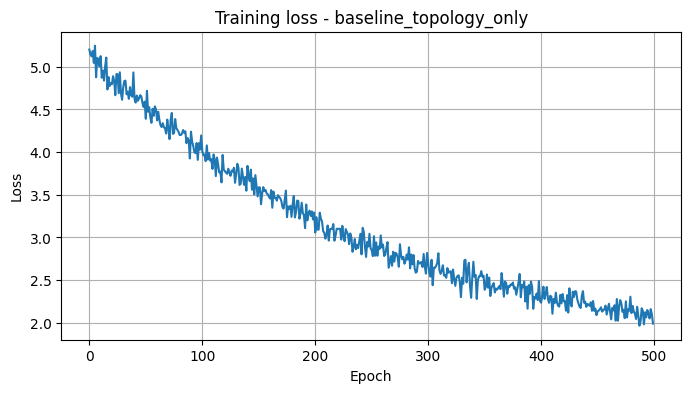

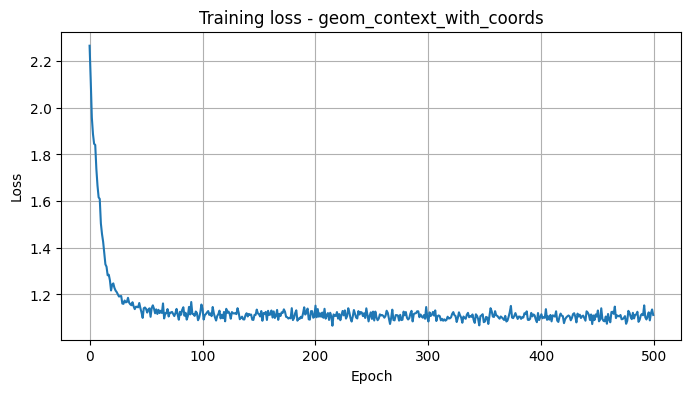

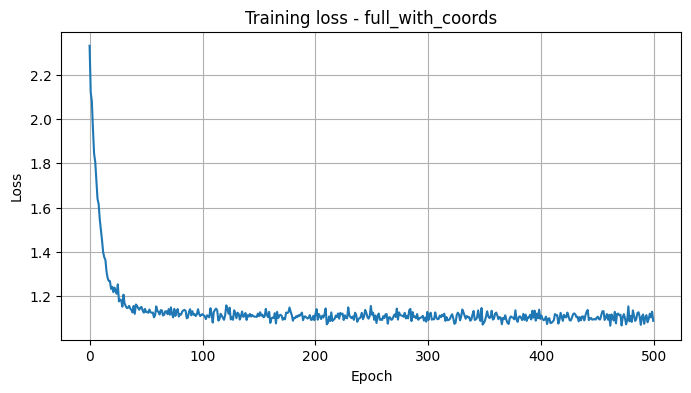

In [370]:
for model_name, hist in training_histories.items():
    plt.figure(figsize=(8, 4))
    plt.plot(hist["total_loss"])
    plt.title(f"Training loss - {model_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

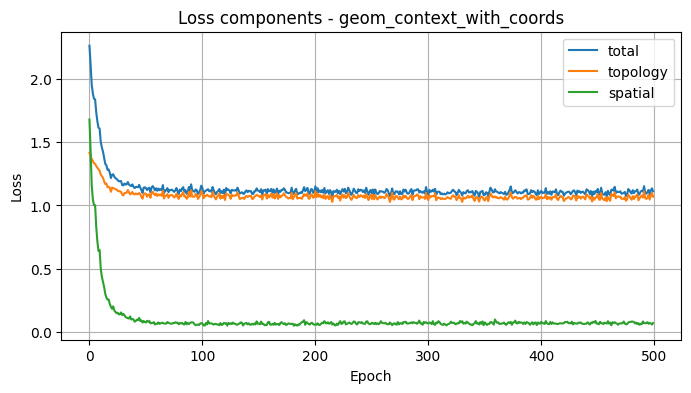

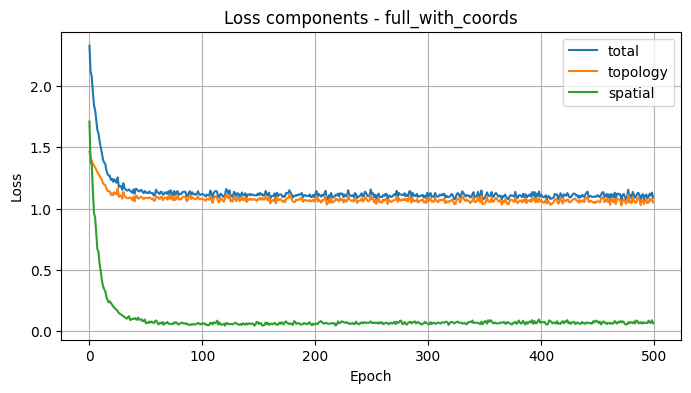

In [371]:
for model_name, hist in training_histories.items():
    if "topo_loss" in hist:
        plt.figure(figsize=(8, 4))
        plt.plot(hist["total_loss"], label="total")
        plt.plot(hist["topo_loss"], label="topology")
        plt.plot(hist["space_loss"], label="spatial")
        plt.title(f"Loss components - {model_name}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.grid(True)
        plt.show()

In [372]:
summary_rows = []

for model_name, hist in training_histories.items():
    row = {
        "model": model_name,
        "final_total_loss": hist["total_loss"][-1],
    }

    if "topo_loss" in hist:
        row["final_topology_loss"] = hist["topo_loss"][-1]
        row["final_spatial_loss"] = hist["space_loss"][-1]
        row["final_regularization_loss"] = hist["reg_loss"][-1]
    else:
        row["final_topology_loss"] = np.nan
        row["final_spatial_loss"] = np.nan
        row["final_regularization_loss"] = np.nan

    summary_rows.append(row)

training_summary_df = pd.DataFrame(summary_rows)
training_summary_df

,model,final_total_loss,final_topology_loss,final_spatial_loss,final_regularization_loss
0,baseline_topology_only,1.990163,NaN,NaN,NaN
1,geom_context_with_coords,1.111901,1.069536,0.068764,79.833160
2,full_with_coords,1.088862,1.049770,0.062608,77.878433
